## Figure 4. remote vs local proportion

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
import seaborn as sns
import copy

In [4]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMind, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new
from spyglass.shijiegu.changeOfMind_remote_interval import find_remote_theta_animal, load_remote_animal

[2025-11-09 15:00:23,722][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[15:00:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:00:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:00:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:00:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:00:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> 

In [5]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (remote_theta_count_per_day, long_theta_count_per_day, intersection)

### Pre- and post- change of mind

In [6]:
params = {"use_1d": True,
          "use_home": False,
          "use_center": False,
          "use_outer": True,
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":5,
          "speed_threshold":4,
          "max_flag": 1}

### Make data

In [10]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
success_animal = {}

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = 'lewis'
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'


In [7]:
def figure4_plotting(animal, list_of_days_animals, encoding_set_animals, classifier_param_name_animals, use_1d = 1, proportion = 0.1):
    loaded_data = load_remote_animal(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
    
    (all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

    (all_info_animal_control, info_animal_control,
     time_intervals_animal_control, arm_identities_animal_control
        ) = (loaded_data['all_info_animal_control'], loaded_data['info_animal_control'],
             loaded_data['time_intervals_animal_control'], loaded_data['arm_identities_animal_control'])

    # tally theta with remote content
    dates, remote_num_trials, session_trial_remote = remote_theta_count_per_day(loaded_data)
    
    # tally theta with long theta content ahead of the animal
    total_num_trials_theta, long_theta_trials, session_trial_long = long_theta_count_per_day(
        animal, list_of_days_animals[animal], proportion = 0.1, delta_t_minus = 5, delta_t_plus = 5, max_flag = 1)
    
    # intersection of 2 sets
    session_trial_both, intersection_ratio_long, intersection_ratio_remote, session_trial_union = intersection(session_trial_long, session_trial_remote)

    
    union_set = [len(session_trial_union[_]) for _ in session_trial_union]
    intersection_set = [len(session_trial_both[_]) for _ in session_trial_both]
    
    long_theta_ratio = np.array(long_theta_trials) / np.array(total_num_trials_theta)
    remote_ratio = np.array(remote_num_trials) / np.array(total_num_trials_theta)
    either_ratio = np.array(union_set) / np.array(total_num_trials_theta)
    intersection_ratio = np.array(intersection_set) / np.array(total_num_trials_theta)

           # the 3 things in return are
           # proportion of all change of mind trials with long theta 
           # proportion of all change of mind trials with remote theta
           # proportion of remote theta trials with long theta
    
    # save as a pickle file
    
    return long_theta_ratio, remote_ratio, intersection_ratio_remote, either_ratio, intersection_ratio, session_trial_union
    

In [244]:
success = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

use_1d = 1
for animal in ["klein"]:#["molly","lewis","julio","eliot","klein"]:
    long_theta_ratio, remote_ratio, intersection_ratio_remote, either_ratio, intersection_ratio, session_trial_union = figure4_plotting(
        animal, list_of_days_animals, encoding_set_animals, classifier_param_name_animals,
        use_1d = 1, proportion = 0.1)
    
    data = {}
    data["long_theta_ratio"] = long_theta_ratio
    data["remote_ratio"] = remote_ratio
    data["intersection_ratio_remote"] = intersection_ratio_remote
    data["either_ratio"] = either_ratio
    data["intersection_ratio"] = intersection_ratio
    data["session_trial_union"] = session_trial_union

    save_name = f"{animal}_figure4_plotting_use1d_{int(use_1d)}"
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")

    success[animal] = True

    

[2025-10-30 17:10:40,922][WARNING]: Skipped checksum for file with hash: 541684b9-bd51-b3dc-9a98-f09038d99575, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_LESFVX368F.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231111_p0.1_use1d1.pkl':
klein20231101_.nwb


[2025-10-30 17:10:49,764][WARNING]: Skipped checksum for file with hash: 4d746652-5b40-83c5-03ad-c71b82e19366, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_N0FJWWVHEU.nwb
[2025-10-30 17:10:58,627][WARNING]: Skipped checksum for file with hash: c99516a7-0ec0-3e0e-5c98-3be1311466af, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_8GAN40UXMB.nwb
[2025-10-30 17:11:07,353][WARNING]: Skipped checksum for file with hash: badecb99-51a9-2ecb-ea9b-b9903c50e81a, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_CBUJW5HGOU.nwb
[2025-10-30 17:11:16,057][WARNING]: Skipped checksum for file with hash: 1c0401c9-84e2-9360-d8d7-4493bbdc231c, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_BRVW0N0KDB.nwb
[2025-10-30 17:11:24,771][WARNING]: Skipped checksum for file with hash: 5493b685-0b0f-268a-2bfa-23b0b5598042, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_78U29XY4JK.nwb
[2025-10-30 17:11:33,547][WARNING]: Skipped checksum for file with hash: 60

klein20231102_.nwb


[2025-10-30 17:11:42,277][WARNING]: Skipped checksum for file with hash: 4742b83d-f1ee-3880-12d0-081fd8770885, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_JQWFHVPKQC.nwb
[2025-10-30 17:11:51,117][WARNING]: Skipped checksum for file with hash: 096dee76-ac68-74f9-01e1-bfaeab9ea3a7, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_DLERZ995MY.nwb
[2025-10-30 17:11:59,859][WARNING]: Skipped checksum for file with hash: 42e4fc27-0e28-9aa2-f0db-75b9dde89a5a, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_30JVLDPIUL.nwb
[2025-10-30 17:12:08,615][WARNING]: Skipped checksum for file with hash: c0764bd4-597b-237a-053a-1f76585c5fad, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_1AMKT07SIQ.nwb
[2025-10-30 17:12:17,400][WARNING]: Skipped checksum for file with hash: 37ca5ca7-719d-6189-f398-b2557f7d1066, and path: /stelmo/nwb/analysis/klein20231103/klein20231103_CG7AUQF7H4.nwb


...

klein20231109_.nwb


[2025-10-30 17:16:34,380][WARNING]: Skipped checksum for file with hash: 56cad260-dbf7-9063-0b24-f1bd1108cdae, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_DPCH8MFMSC.nwb
[2025-10-30 17:16:43,323][WARNING]: Skipped checksum for file with hash: 3b24886f-8f85-972d-0dae-34e0e4060a33, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_7F8S112BEZ.nwb
[2025-10-30 17:16:52,234][WARNING]: Skipped checksum for file with hash: 0a78ec4a-91d0-f063-46fe-d4f600454f71, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_5FNXSF1O0D.nwb
[2025-10-30 17:17:01,310][WARNING]: Skipped checksum for file with hash: b37d7e19-843e-c51f-aced-77a78e50cf6a, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_6KMLS7MBWB.nwb
[2025-10-30 17:17:10,196][WARNING]: Skipped checksum for file with hash: 8f40f4f9-3db7-8e4c-4534-6fae034a74b0, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_MO4RSHTX71.nwb


klein20231111_.nwb


[2025-10-30 17:17:19,088][WARNING]: Skipped checksum for file with hash: e16d12cf-6afd-d8d1-22a1-be0d68382c2e, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_V95AGW5KFY.nwb
[2025-10-30 17:17:27,906][WARNING]: Skipped checksum for file with hash: 2021a037-1606-94d3-807a-561d7a08a60d, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_TV1V7N65P6.nwb
[2025-10-30 17:17:37,016][WARNING]: Skipped checksum for file with hash: b1c2f348-a84d-0510-2129-68efa9dadd16, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_U5EZHJ6LZZ.nwb
[2025-10-30 17:17:45,936][WARNING]: Skipped checksum for file with hash: c9f2fd09-9c83-0667-3a54-390a122e717e, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_CJ8STUWBDY.nwb


Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4_plotting_use1d_1.pkl


In [220]:
#%debug

In [242]:
success

{'lewis': True}

In [8]:
from matplotlib.colors import Normalize
from scipy import stats
import starbars
import matplotlib as mpl
cmap = mpl.colormaps['cool']

### Load and plot

In [209]:
remote_ratio

array([0.25925926, 0.36585366, 0.48275862, 0.41935484, 0.61538462,
       0.125     , 0.36363636, 0.14285714, 0.54545455, 0.52941176])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4_plotting_use1d_1.pkl':
p_value 0.09367382883503171
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4_plotting_use1d_1.pkl':
p_value 0.5796911158059574
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4_plotting_use1d_1.pkl':
p_value 0.5291333003818577
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4_plotting_use1d_1.pkl':
p_value 0.019865629628717612
3.9600000000000004 0.03
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4_plotting_use1d_1.pkl':
p_value 0.0055051595680419875
5.0600000000000005 0.03


(-0.2, 5.0)

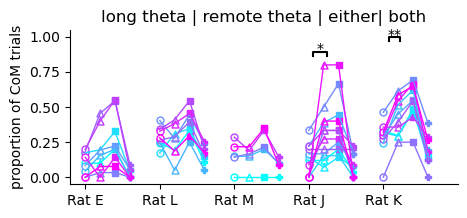

In [19]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

use_1d = 1
fig, axes = plt.subplots(1, 1, figsize=(5, 2),sharey = True)

animal_ind = 0
animals = ["eliot","lewis","molly","julio","klein"]
for animal in animals:#,'molly','lewis']:

    save_name = f"{animal}_figure4_plotting_use1d_{int(use_1d)}"
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    (long_theta_ratio, remote_ratio,
     intersection_ratio_remote,
     either_ratio,
     intersection_ratio) = (loaded_data["long_theta_ratio"], loaded_data["remote_ratio"],
                                                 loaded_data["intersection_ratio_remote"],
                                                 loaded_data["either_ratio"],loaded_data["intersection_ratio"])

    dates_to_plot = list_of_days_animals[animal]

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    dot_size = 25
    for ind in range(len(dates_to_plot)):
        
        axes.scatter(animal_ind, long_theta_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "o")
        axes.scatter(animal_ind+0.2, remote_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "^")
        axes.scatter(animal_ind+0.4, either_ratio[ind], color = cmap(norm(ind)), s = dot_size, marker = "s")
        axes.scatter(animal_ind+0.6, intersection_ratio[ind], color = cmap(norm(ind)), s = dot_size, marker = "P")
        axes.plot(np.array([0,0.2,0.4,0.6]) + animal_ind,[long_theta_ratio[ind],
                                                  remote_ratio[ind],
                                                  either_ratio[ind],
                                                  intersection_ratio[ind]],color = cmap(norm(ind)),linewidth = 1)

    #### add stats
    logratio1 = long_theta_ratio
    logratio2 = remote_ratio
    #logratio1[np.isinf(logratio1)] = -5
    #logratio2[np.isinf(logratio2)] = -5
    t_statistic, p_value = stats.ttest_rel(logratio1,logratio2)
    print("p_value",p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))])
    ########
    
    animal_ind += 1

#axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_xlim([-1,len(animals) + 1]);
axes.set_title("long theta | remote theta | either| both")
axes.set_ylabel("proportion of CoM trials")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/"
plt.savefig(file_path + "counting.pdf",bbox_inches='tight')
plt.savefig(file_path + "counting.png",bbox_inches='tight')

axes.set_xlim([-0.2,len(animals)])

### a smaller plot

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4_plotting_use1d_1.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4_plotting_use1d_1.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4_plotting_use1d_1.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4_plotting_use1d_1.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4_plotting_use1d_1.pkl':


(-0.2, 4.5)

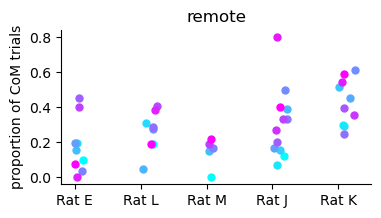

In [36]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

use_1d = 1
fig, axes = plt.subplots(1, 1, figsize=(4, 2),sharey = True)

animal_ind = 0
animals = ["eliot","lewis","molly","julio","klein"]
for animal in animals:#,'molly','lewis']:

    save_name = f"{animal}_figure4_plotting_use1d_{int(use_1d)}"
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    (long_theta_ratio, remote_ratio,
     intersection_ratio_remote,
     either_ratio,
     intersection_ratio) = (loaded_data["long_theta_ratio"], loaded_data["remote_ratio"],
                                                 loaded_data["intersection_ratio_remote"],
                                                 loaded_data["either_ratio"],loaded_data["intersection_ratio"])

    dates_to_plot = list_of_days_animals[animal]

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    dot_size = 25
    for ind in range(len(dates_to_plot)):
        
        #axes.scatter(animal_ind, long_theta_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "o")
        #axes.scatter(animal_ind+0.2, remote_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "^")
        axes.scatter(animal_ind+np.random.rand()*0.25, remote_ratio[ind], color = cmap(norm(ind)), s = dot_size)
        #axes.scatter(animal_ind+0.6, intersection_ratio[ind], color = cmap(norm(ind)), s = dot_size, marker = "P")
 
    
    animal_ind += 1

#axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_title("remote")
axes.set_ylabel("proportion of CoM trials")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/"
plt.savefig(file_path + "counting_remote.pdf",bbox_inches='tight', transparent=True)
plt.savefig(file_path + "counting_remote.png",bbox_inches='tight', transparent=True)

axes.set_xlim([-0.2,len(animals)-0.5])

### End here

### Start here for loading remote parsing

In [193]:
animal = 'klein'

In [194]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = 0.1, use_1d = 1)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

(all_info_animal_control, info_animal_control,
     time_intervals_animal_control, arm_identities_animal_control
        ) = (loaded_data['all_info_animal_control'], loaded_data['info_animal_control'],
             loaded_data['time_intervals_animal_control'], loaded_data['arm_identities_animal_control'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231111_p0.1_use1d1.pkl':


In [192]:
info_animal

[['julio20230802_.nwb', '06_Seq2Session3', [69]],
 ['julio20230803_.nwb', '08_Seq2Session4', [51, 51]],
 ['julio20230803_.nwb', '10_Seq2Session5', [9]],
 ['julio20230803_.nwb', '12_Seq2Session6', [13, 13]],
 ['julio20230803_.nwb', '12_Seq2Session6', [52]],
 ['julio20230804_.nwb', '04_Seq2Session2', [70, 70]],
 ['julio20230805_.nwb', '04_Seq2Session2', [20]],
 ['julio20230805_.nwb', '04_Seq2Session2', [27, 27, 27]],
 ['julio20230805_.nwb', '06_Seq2Session3a', [17]],
 ['julio20230808_.nwb', '02_Seq2Session1', [67, 67, 67]],
 ['julio20230808_.nwb', '08_Seq2Session4', [27]],
 ['julio20230809_.nwb', '02_Seq2Session1', [26, 26, 26, 26, 26, 26]],
 ['julio20230810_.nwb', '04_Seq2Session2', [51]],
 ['julio20230810_.nwb', '06_Seq2Session3', [12]],
 ['julio20230810_.nwb', '08_Seq2Session4', [18]],
 ['julio20230810_.nwb', '08_Seq2Session4', [73]],
 ['julio20230811_.nwb', '09_Seq2Session5', [17]]]

In [ ]:
"""
['julio20230803_.nwb', '08_Seq2Session4', [51, 51]],
['julio20230803_.nwb', '10_Seq2Session5', [9]],
['julio20230803_.nwb', '12_Seq2Session6', [13, 13]],
['julio20230803_.nwb', '12_Seq2Session6', [52]],
['julio20230808_.nwb', '02_Seq2Session1', [67, 67, 67]],
['julio20230808_.nwb', '08_Seq2Session4', [27]],


['eliot20221020_.nwb', '12_Seq2Session6', [19]],
 ['eliot20221020_.nwb', '12_Seq2Session6', [28]],
 ['eliot20221020_.nwb', '12_Seq2Session6', [60]],
 ['eliot20221021_.nwb', '08_Seq2Session4', [60]],
 ['eliot20221021_.nwb', '08_Seq2Session4', [78]],
"""

### End here

In [126]:
def plot(posterior_arm_pre, posterior_arm_control_pre, arm_position, ax, list_of_days, labels):
    posterior_arm_pre_np = np.array(posterior_arm_pre).squeeze()
    posterior_arm_control_pre_np = np.array(posterior_arm_control_pre).squeeze()
    
    mean_pre = np.nanmean(posterior_arm_pre_np, axis = 0)
    sd_pre = np.nanstd(posterior_arm_pre_np, axis = 0)
    
    mean_pre_control = np.nanmean(posterior_arm_control_pre_np, axis = 0)
    sd_pre_control = np.nanstd(posterior_arm_control_pre_np, axis = 0)
    
    for posterior_arm_ in posterior_arm_pre_np:
        ax.plot(np.arange(len(posterior_arm_)),posterior_arm_, 'C1', alpha = 0.2, linewidth = 1)
    
    for posterior_arm_ in posterior_arm_control_pre_np:
        ax.plot(np.arange(len(posterior_arm_)),posterior_arm_, 'C0', alpha = 0.2, linewidth = 1)

    # mean trace
    ax.plot(np.arange(len(mean_pre)), mean_pre, linewidth = 3, color = 'C1', zorder = 100, label = labels[0])
    ax.plot(np.arange(len(mean_pre_control)), mean_pre_control, linewidth = 3, color = 'C0', zorder = 99, label = labels[1])

    # shading
    CI_upper = (mean_pre + sd_pre).reshape((-1,1))
    CI_upper = np.min(np.hstack([CI_upper, np.ones_like(CI_upper)]),axis = 1)

    CI_upper_control = ( mean_pre_control + sd_pre_control).reshape((-1,1))
    CI_upper_control = np.min(np.hstack([CI_upper_control, np.ones_like(CI_upper_control)]),axis = 1)
    
    ax.fill_between(np.arange(len(posterior_arm_)), mean_pre - sd_pre, CI_upper,
                    alpha = 0.4, color = 'C1', zorder = 200, label = labels[0])
    ax.fill_between(np.arange(len(posterior_arm_)), mean_pre_control - sd_pre_control, CI_upper_control,
                    alpha = 0.4, color = 'C0', zorder = 200, label = labels[1])

    ax.set_xticks(np.arange(len(posterior_arm_)))
    ax.set_xticklabels([str(int(np.round(p))) for p in np.mean(arm_position, axis = 1)])
    list_of_days_short = [d[4:8] for d in list_of_days]
    ax.set_title(f"{animal}\n{list_of_days_short}\nlocal posterior when the rat is in outer arm")
    ax.set_ylabel("probability")
    ax.set_xlabel("outer arm bins (10 cm)")
    ax.set_ylim([0,1.1])
    ax.legend()

### Load data

In [179]:
animal = "molly"
list_of_days = ["20220415","20220416","20220417","20220418","20220419","20220420"]

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

data = load_remote_animal_figure7c(animal, list_of_days, encoding_set, classifier_param_name,
                                   proportion = 0.1, use_1d = 1)


NameError: name 'load_remote_animal_figure7c' is not defined

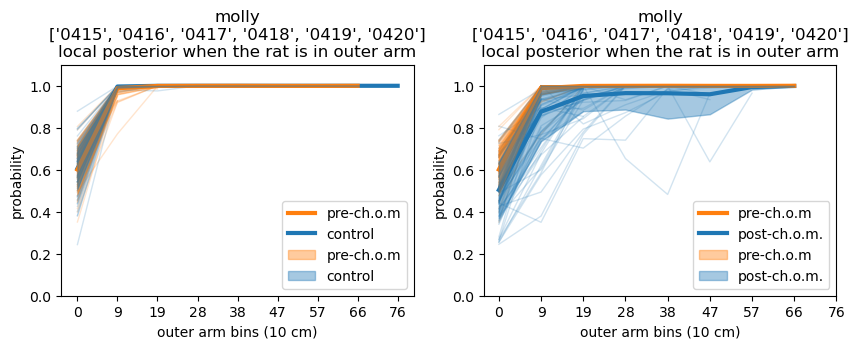

In [127]:
fig, axes = plt.subplots(1,2,figsize = (10,3))
plot(data["posterior_arm_pre"], data["posterior_arm_control_pre"], data["arm_position"], axes[0], list_of_days, ["pre-ch.o.m","control"])
plot(data["posterior_arm_pre"], data["posterior_arm_post"], data["arm_position"], axes[1],list_of_days, ["pre-ch.o.m","post-ch.o.m."])
